In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

emotion_mapping = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# 读取 CSV
csv_path = r'..\datasets\fer2013\fer2013.csv'
data = pd.read_csv(csv_path)

# 过滤训练集示例
train_data = data[data['Usage'] == 'Training']

# 随机选择一个样本
sample = train_data.sample(1).iloc[0]
emotion = sample['emotion']
pixels = np.array([int(p) for p in sample['pixels'].split()]).reshape(48, 48)

# 显示图像
plt.imshow(pixels, cmap='gray')
plt.title(f'Emotion label: {emotion_mapping[emotion]}')
plt.axis('off')
plt.show()

# 随机选择一个样本
sample = train_data.sample(1).iloc[0]
emotion = sample['emotion']
pixels = np.array([int(p) for p in sample['pixels'].split()]).reshape(48, 48)

# 显示图像
plt.imshow(pixels, cmap='gray')
plt.title(f'Emotion label: {emotion_mapping[emotion]}')
plt.axis('off')
plt.show()

# 随机选择一个样本
sample = train_data.sample(1).iloc[0]
emotion = sample['emotion']
pixels = np.array([int(p) for p in sample['pixels'].split()]).reshape(48, 48)

# 显示图像
plt.imshow(pixels, cmap='gray')
plt.title(f'Emotion label: {emotion_mapping[emotion]}')
plt.axis('off')
plt.show()

In [2]:
%env KMP_DUPLICATE_LIB_OK=TRUE
%cd ..
# ! python .\evaluate.py network=vgg name=min_vgg_ReduceLROnPlateau restore_epoch=20

env: KMP_DUPLICATE_LIB_OK=TRUE
c:\Users\Aaron\source\repos\GitHub\yhd12138\VSCode\fer2013


In [ ]:
%env KMP_DUPLICATE_LIB_OK=TRUE
# %cd fer2013/
! python .\evaluate.py network=vgg name=min_vgg_CosLR-1e-4_6Augs_200ep restore_epoch=119

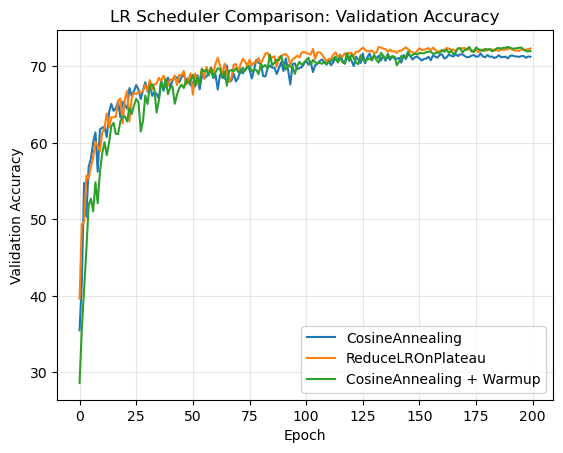

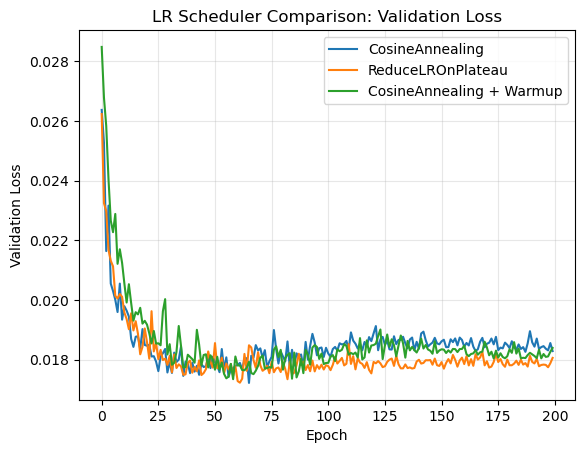

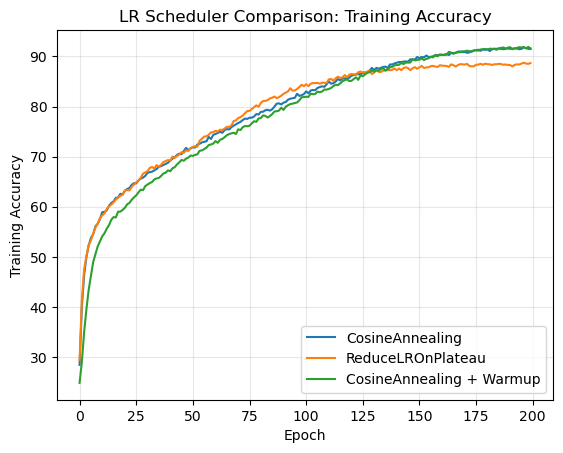

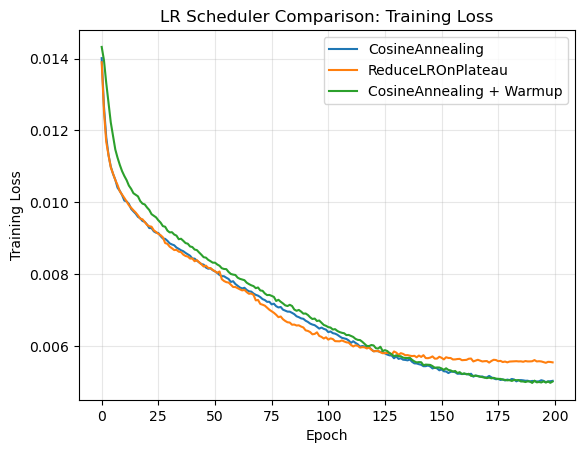

In [13]:
import torch
import matplotlib.pyplot as plt

paths = {
    "CosineAnnealing": "checkpoints/min_vgg_CosLR-1e-4_6Augs_200ep_LS/epoch_200",
    "ReduceLROnPlateau": "checkpoints/min_vgg_ReduceLROnPlateau_6Augs_200ep_LS/epoch_200",
    "CosineAnnealing + Warmup": "checkpoints/min_vgg_CosLRwWarmup-20_6Augs_200ep_LS/epoch_200"
}

plt.figure()

for name, path in paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    
    train_loss, val_loss, train_acc, val_acc = checkpoint['logs']
    
    plt.plot(val_acc, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("LR Scheduler Comparison: Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, path in paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    
    train_loss, val_loss, train_acc, val_acc = checkpoint['logs']
    
    plt.plot(val_loss, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("LR Scheduler Comparison: Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, path in paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    
    train_loss, val_loss, train_acc, val_acc = checkpoint['logs']
    
    plt.plot(train_acc, label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("LR Scheduler Comparison: Training Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name, path in paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    
    train_loss, val_loss, train_acc, val_acc = checkpoint['logs']
    
    plt.plot(train_loss, label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LR Scheduler Comparison: Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()